# Halo Mass Function

Pooled-halo HMF (halos from all selected subvolumes are binned together). Compare to theoretical predictions from the `hmf` library.

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

import galform_analysis
from galform_analysis import set_base_dir, get_base_dir, SimulationConfig, load_redshift_mapping

mpl.setconfig()

# Configure the path to your GALFORM output directory once per session:
# set_base_dir('/cosma5/data/durham/<user>/Galform_Out/L800/model')
BASE_DIR = str(get_base_dir())
SIM = 'L800'

## Single subvolume

In [2]:
from galform_analysis.analysis.mass_functions.hmf import (
    hmf_given_redshift_and_subvolume,
    avg_hmf_given_redshift_and_subvolumes,
    hmfs_given_redshifts_and_subvolume,
)
from galform_analysis.analysis.mass_functions.theoretical_hmf import compute_theoretical_hmfs
from galform_analysis.config import DEFAULT_HALO_MASS_BINS, get_snapshot_redshift
import os

iz_path = os.path.join(BASE_DIR, 'iz155')
res = hmf_given_redshift_and_subvolume(iz_path, ivol=0)
print(f"z={res['z']:.4f},  halos in sample={res['counts'].sum():,}")

z=1.4955,  halos in sample=59,562


## Averaged over subvolumes, with theory comparison

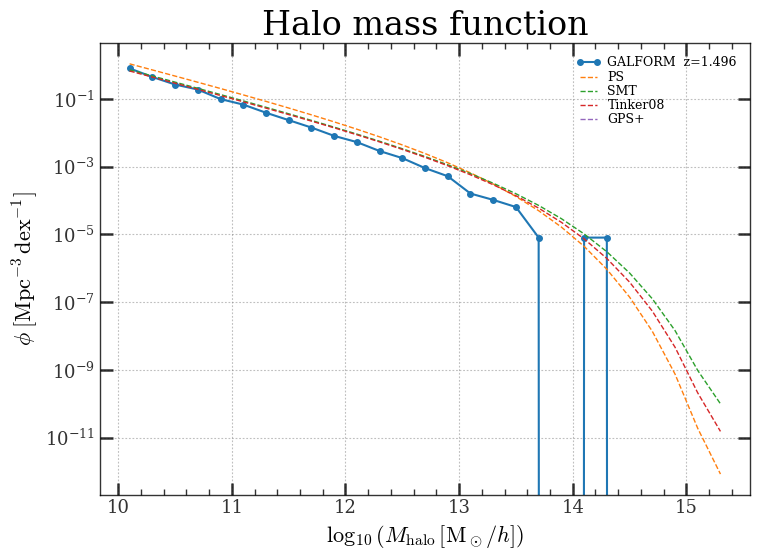

In [3]:
IZ_NUM = 155
IVOLS  = list(range(4))

z = get_snapshot_redshift(f'iz{IZ_NUM}', SIM)
hmf = avg_hmf_given_redshift_and_subvolumes(IZ_NUM, IVOLS, base_dir=BASE_DIR)
theory = compute_theoretical_hmfs(z=z, bins=DEFAULT_HALO_MASS_BINS, use_mvir=True)

fig, ax = plt.subplots()
ax.plot(hmf['centers'], hmf['phi'], 'o-', ms=4, lw=1.5, label=f'GALFORM  z={z:.3f}')
for name, vals in theory.items():
    ax.plot(hmf['centers'], vals, '--', lw=1, label=name)
ax.set_yscale('log')
ax.set_xlabel(r'$\log_{{10}}(M_{{\rm halo}}\,[\mathrm{{M}}_\odot/h])$')
ax.set_ylabel(r'$\phi\;[\mathrm{{Mpc}}^{{-3}}\,\mathrm{{dex}}^{{-1}}]$')
ax.set_title('Halo mass function')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## Redshift evolution

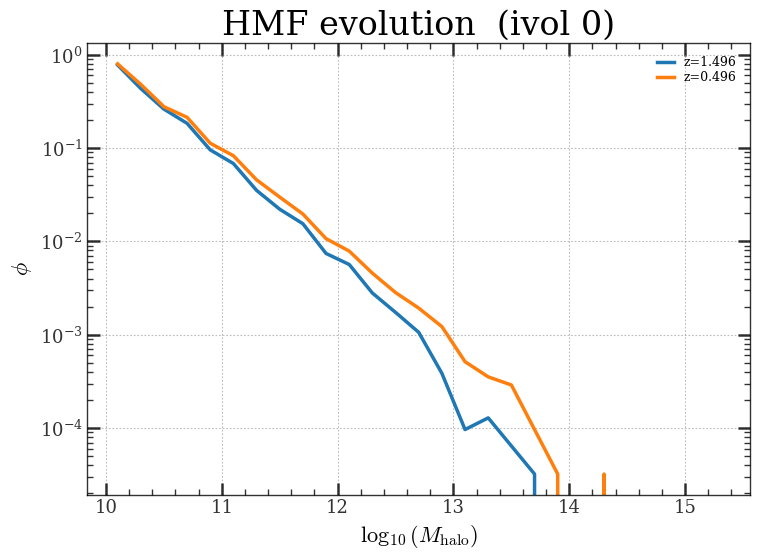

In [4]:
IZ_NUMS = [82, 120, 155, 207]
IVOL    = 0

import polars as pl
df = hmfs_given_redshifts_and_subvolume(IVOL, IZ_NUMS, base_dir=BASE_DIR)
if df is not None:
    fig, ax = plt.subplots()
    for (z_val,), grp in df.group_by('z', maintain_order=True):
        ax.plot(grp['log_M'], grp['phi'], label=f'z={z_val:.3f}')
    ax.set_yscale('log')
    ax.set_xlabel(r'$\log_{{10}}(M_{{\rm halo}})$')
    ax.set_ylabel(r'$\phi$')
    ax.set_title('HMF evolution  (ivol 0)')
    ax.legend(fontsize=9)
    fig.tight_layout()
    plt.show()